# Dyck Counting Features for Four Models (50% Noise)

- training sanity checks
- next-token accuracy by position
- counting-feature probes at a fixed prefix
- supervised projection plots
- PCA / rotated-plane diagnostics
- prefix sweep plots
- direction-arithmetic plots

This notebook keeps the reference-style plot families, but runs them sequentially for `rnn -> lstm -> transformer -> mamba` under the current project setting.

## 0. Path Setup

In [16]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ROOT

PosixPath('/home/hp_twist_shan/Research/Hidden State Evaluation')

## 1. Imports

In [17]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from hse.experiments.dyck import DEFAULT_DYCK_MODEL_SPECS, DEFAULT_DYCK_TASKS
from hse.models import build_model
from hse.tasks.dyck import DyckConfig, DyckSampler
from hse.utils import evaluate_causal_lm, train_causal_lm

sns.set_theme(style="whitegrid", context="talk")

## 2. Global Knobs

These defaults are now set to a formal `dyck_50_noise` experiment configuration rather than a smoke test. The run writes to a separate `formal` results directory so it does not silently reuse the earlier lightweight outputs.

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TASK_NAME = "dyck_50_noise"
NOTEBOOK_BASE_TASK = dict(DEFAULT_DYCK_TASKS[TASK_NAME])
TASK_RUN_NAME = TASK_NAME
DYCK_PAIRS = NOTEBOOK_BASE_TASK["dyck_pairs"]
TOTAL_LENGTH = NOTEBOOK_BASE_TASK["total_length"]
SEQ_LEN = NOTEBOOK_BASE_TASK["seq_len"]
REPEAT_PROB = NOTEBOOK_BASE_TASK["repeat_prob"]
N_TASKS = NOTEBOOK_BASE_TASK["n_tasks"]
PREFIX_PROBE_MAX_LEN = NOTEBOOK_BASE_TASK["prefix_probe_max_len"]
TASK_OVERRIDES = {
    "dyck_pairs": DYCK_PAIRS,
    "total_length": TOTAL_LENGTH,
    "seq_len": SEQ_LEN,
    "repeat_prob": REPEAT_PROB,
    "n_tasks": N_TASKS,
    "prefix_probe_max_len": PREFIX_PROBE_MAX_LEN,
}
MODEL_TYPES = ["rnn", "lstm", "transformer", "mamba"]
STATE_KIND_BY_MODEL = {"rnn": "h", "lstm": "c", "transformer": "h", "mamba": "h"}

TRAINING_STEPS = 10000
BATCH_SIZE = 128
LEARNING_RATE = 3e-4
EVAL_EVERY = 200
TRAIN_SEED = 0

PREFIX_LENGTH = 8
LAYER_INDEX = -1
N_PROBE_SAMPLES = 20000
PROBE_BATCH_SIZE = 1024
BALANCE_PROBE_BY = "height"
BALANCE_SEED = 0

SWEEP_PREFIX_LENGTHS = list(range(2, TOTAL_LENGTH, 2))
SWEEP_N_SAMPLES = 8192

FORCE_RETRAIN = False
EXPERIMENT_TAG = "formal"
RESULTS_ROOT = ROOT / "results" / "notebooks" / "dyck_reference_style" / EXPERIMENT_TAG / TASK_RUN_NAME
RESULTS_ROOT

PosixPath('/home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_reference_style/formal/dyck_50_noise')

## 3. Core Helpers

In [19]:
def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_task_kwargs(task_name=TASK_NAME):
    task_kwargs = dict(DEFAULT_DYCK_TASKS[task_name])
    task_kwargs.update(TASK_OVERRIDES)
    task_kwargs["device"] = DEVICE
    return task_kwargs


def get_task_config(task_name=TASK_NAME):
    return DyckConfig(**get_task_kwargs(task_name))


def get_model_spec(model_type):
    spec = dict(DEFAULT_DYCK_MODEL_SPECS[model_type])
    if model_type == "lstm":
        spec["state_kind"] = "c"
    return spec


def get_run_dir(model_type):
    return RESULTS_ROOT / f"{model_type}_seed{TRAIN_SEED}"


def build_fresh_model(model_type):
    spec = get_model_spec(model_type)
    model_kwargs = {k: v for k, v in spec.items() if k != "state_kind"}
    cfg = get_task_config()
    return build_model(model_name=model_type, vocab_size=cfg.vocab_size, **model_kwargs).to(DEVICE)


def make_sampler(seed_offset=0):
    return DyckSampler(get_task_config(), seed=TRAIN_SEED + seed_offset)


def load_or_train_model(model_type):
    run_dir = get_run_dir(model_type)
    checkpoint_path = run_dir / "checkpoints" / "model_final.pt"
    metrics_path = run_dir / "metrics.json"
    config_path = run_dir / "config.json"

    model = build_fresh_model(model_type)
    train_sampler = make_sampler(seed_offset=0)

    if checkpoint_path.exists() and metrics_path.exists() and not FORCE_RETRAIN:
        payload = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(payload["model"])
        return {
            "model": model,
            "train_sampler": train_sampler,
            "metrics": load_json(metrics_path),
            "run_dir": run_dir,
            "config": load_json(config_path) if config_path.exists() else None,
        }

    run_dir.mkdir(parents=True, exist_ok=True)
    spec = get_model_spec(model_type)
    save_json(
        {
            "task_name": TASK_RUN_NAME,
            "base_task_name": TASK_NAME,
            "task_overrides": TASK_OVERRIDES,
            "task": get_task_kwargs(),
            "model_type": model_type,
            "model_spec": spec,
            "training_steps": TRAINING_STEPS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "device": DEVICE,
            "seed": TRAIN_SEED,
        },
        config_path,
    )
    train_log = train_causal_lm(
        model=model,
        sampler=train_sampler,
        steps=TRAINING_STEPS,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        run_dir=run_dir,
        eval_every=EVAL_EVERY,
        device=DEVICE,
    )
    eval_metrics = evaluate_causal_lm(
        model=model,
        sampler=make_sampler(seed_offset=100),
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    metrics = {"train": train_log, "eval": eval_metrics}
    save_json(metrics, metrics_path)
    return {
        "model": model,
        "train_sampler": train_sampler,
        "metrics": metrics,
        "run_dir": run_dir,
        "config": load_json(config_path),
    }


## 4. Training Sanity Checks

In [20]:
def moving_average_edge(x, window=11):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x.copy()
    left = window // 2
    right = window - 1 - left
    padded = np.pad(x, (left, right), mode="edge")
    return np.convolve(padded, np.ones(window) / window, mode="valid")


@torch.no_grad()
def compute_position_accuracy(model, sampler, *, num_samples=2048, batch_size=512):
    model.eval().to(DEVICE)
    numer = None
    denom = None
    total_correct = 0.0
    total_count = 0.0
    remaining = int(num_samples)

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        dyck_mask = batch.dyck_mask.to(DEVICE)
        logits = model(tokens)
        pred = logits[:, :-1, :].argmax(dim=-1)
        target = tokens[:, 1:]
        eval_mask = dyck_mask[:, 1:]
        correct = (pred == target) & eval_mask

        batch_numer = correct.float().sum(dim=0).detach().cpu()
        batch_denom = eval_mask.float().sum(dim=0).detach().cpu()
        numer = batch_numer if numer is None else numer + batch_numer
        denom = batch_denom if denom is None else denom + batch_denom
        total_correct += float(batch_numer.sum())
        total_count += float(batch_denom.sum())
        remaining -= bs

    acc = torch.full_like(denom, float("nan"))
    valid = denom > 0
    acc[valid] = numer[valid] / denom[valid]
    return np.arange(acc.numel()), acc.numpy(), total_correct / max(total_count, 1.0)


def plot_loss_sanity(model_type, metrics):
    train_df = pd.DataFrame(metrics["train"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(train_df["step"], train_df["loss"], lw=0.8, alpha=0.55, label="raw")
    if len(train_df) >= 5:
        smooth = moving_average_edge(train_df["loss"], window=min(11, len(train_df) if len(train_df) % 2 == 1 else len(train_df) - 1))
        axes[0].plot(train_df["step"], smooth, lw=1.6, label="smoothed")
    axes[0].set_title(f"{model_type.upper()} train loss")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("cross entropy")
    axes[0].legend(frameon=False)
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(train_df["step"], train_df["eval_loss"], label="eval loss", lw=1.8)
    axes[1].set_title(f"{model_type.upper()} eval loss")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("cross entropy")
    axes[1].legend(frameon=False)
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_accuracy_sanity(model_type, model):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    summary = {}
    pos, acc, mean_acc = compute_position_accuracy(model, make_sampler(seed_offset=100))
    ax.plot(pos, acc, label=f"eval mean={mean_acc:.3f}")
    summary["eval"] = mean_acc
    ax.set_title(f"{model_type.upper()} Dyck-only next-token accuracy")
    ax.set_xlabel("target position")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    print(f"{model_type.upper()} mean accuracy: " + ", ".join(f"{k}={v:.4f}" for k, v in summary.items()))
    return summary

In [21]:
loaded_models = {}
sanity_results = {}

## 4A. Train RNN

SANITY: rnn


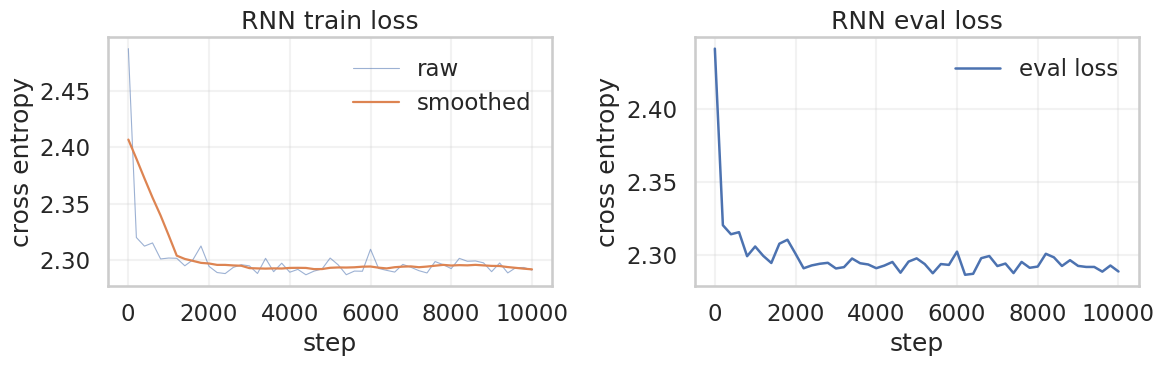

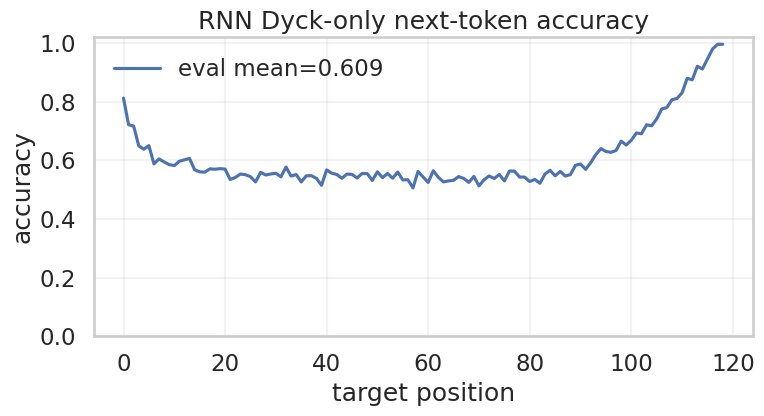

RNN mean accuracy: eval=0.6090


In [22]:
model_type = "rnn"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])

## 4B. Train LSTM

SANITY: lstm


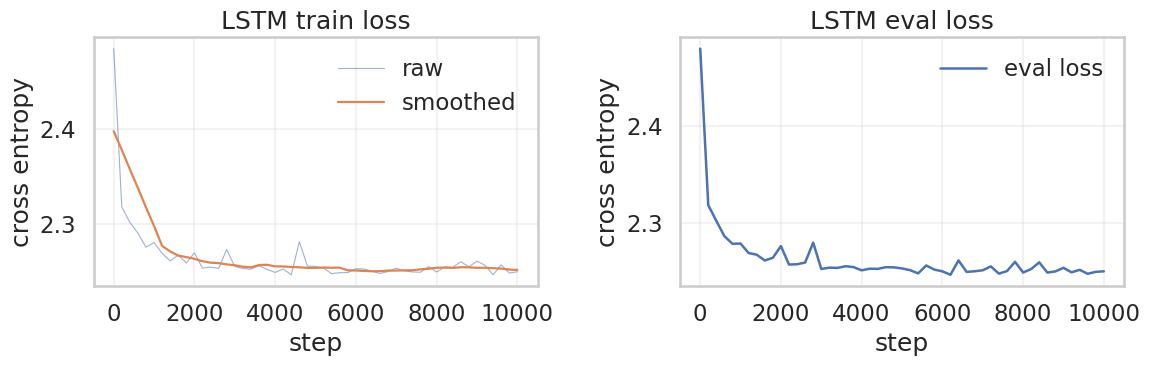

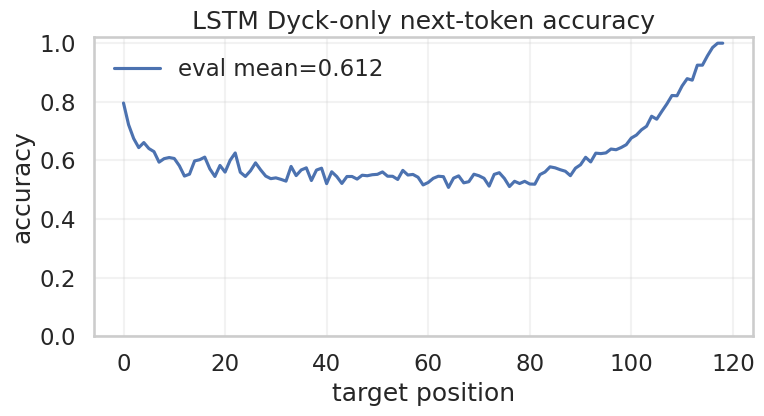

LSTM mean accuracy: eval=0.6122


In [23]:
model_type = "lstm"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])

## 4C. Train Transformer

SANITY: transformer


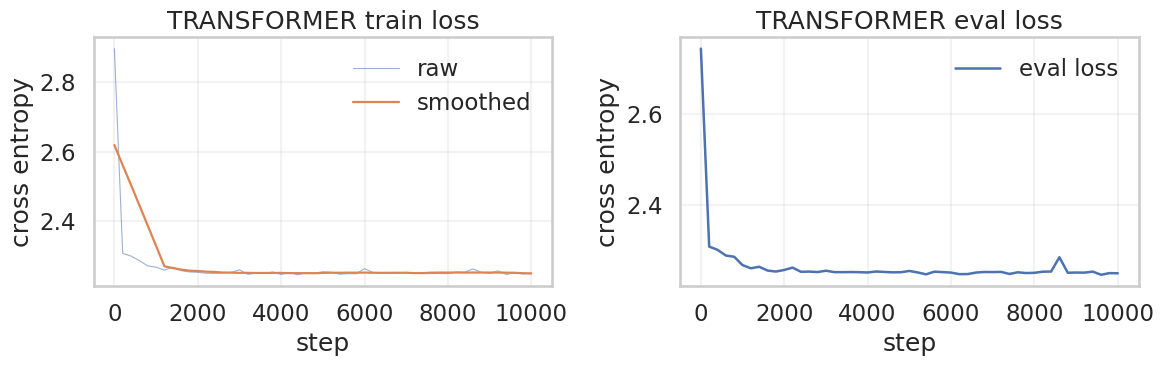

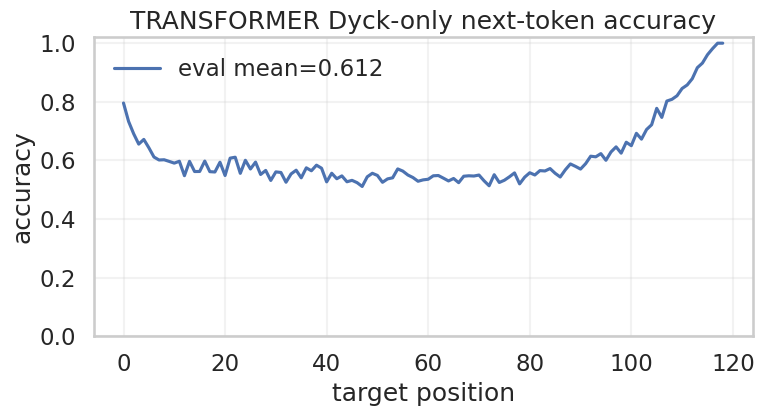

TRANSFORMER mean accuracy: eval=0.6122


In [24]:
model_type = "transformer"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])

## 4D. Train Mamba

SANITY: mamba


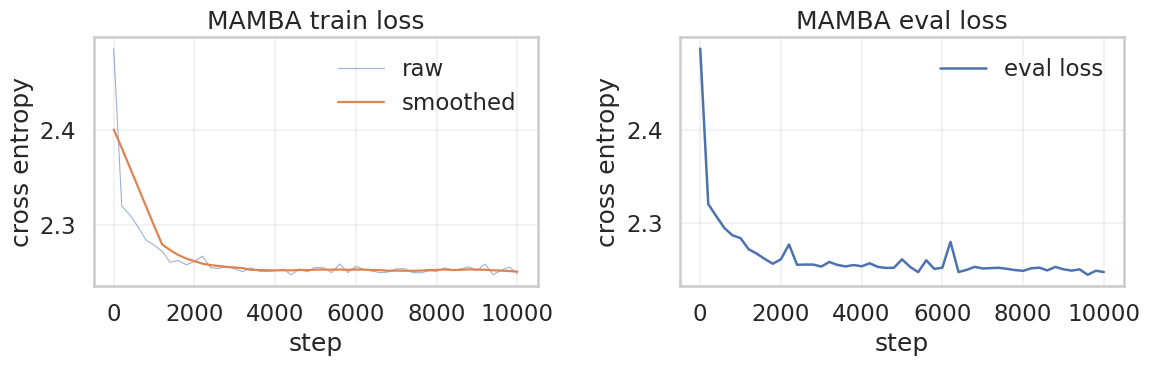

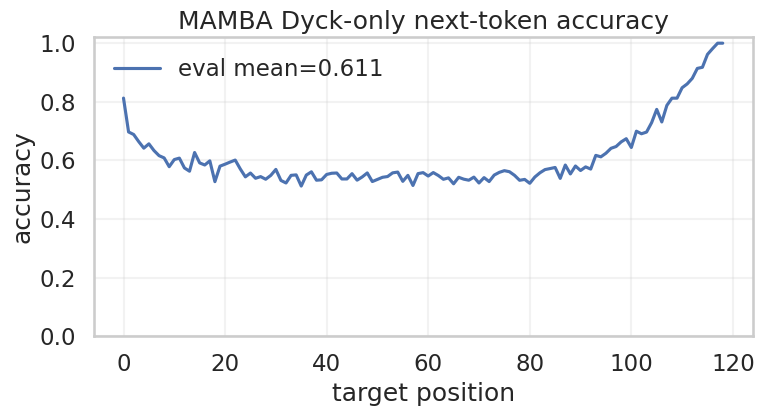

MAMBA mean accuracy: eval=0.6113


In [25]:
model_type = "mamba"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])

## 5. Counting Probe Data and Probe Fitting

In [26]:
@torch.no_grad()
def sample_hidden_count_matrix(
    model,
    sampler,
    *,
    prefix_length=PREFIX_LENGTH,
    layer_index=LAYER_INDEX,
    state_kind="h",
    n_samples=N_PROBE_SAMPLES,
    batch_size=PROBE_BATCH_SIZE,
):
    cfg = sampler.config
    assert 1 <= prefix_length <= cfg.total_length
    model.eval().to(DEVICE)

    hs, prefixes, lefts, rights, heights, pair_ids, next_tokens = [], [], [], [], [], [], []
    remaining = int(n_samples)
    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        dyck_mask = batch.dyck_mask.to(DEVICE)
        dyck_steps = batch.dyck_steps.to(DEVICE)
        states = model.extract_states(tokens, layer_index=layer_index, state_kind=state_kind)
        prefix_hits = (dyck_mask.long().cumsum(dim=1) == prefix_length) & dyck_mask
        assert prefix_hits.any(dim=1).all(), "Every sample should contain the requested number of Dyck tokens."
        state_positions = prefix_hits.float().argmax(dim=1)
        row_ids = torch.arange(bs, device=DEVICE)
        h = states[row_ids, state_positions, :].detach().cpu().numpy()

        open_token = cfg.open_token
        close_token = cfg.close_token
        prefix_steps = dyck_steps[:, :prefix_length]
        prefix = torch.where(
            prefix_steps > 0,
            torch.full_like(prefix_steps, open_token, dtype=torch.long),
            torch.full_like(prefix_steps, close_token, dtype=torch.long),
        ).detach().cpu().numpy()
        sign = np.where(prefix == open_token, 1, np.where(prefix == close_token, -1, 0))
        left = (sign == 1).sum(axis=1)
        right = (sign == -1).sum(axis=1)
        height = left - right
        pair_id = left * (prefix_length + 1) + right

        hs.append(h)
        prefixes.append(prefix)
        lefts.append(left)
        rights.append(right)
        heights.append(height)
        pair_ids.append(pair_id)
        if prefix_length < cfg.total_length:
            next_steps = dyck_steps[:, prefix_length]
            next_tok = torch.where(
                next_steps > 0,
                torch.full_like(next_steps, open_token, dtype=torch.long),
                torch.full_like(next_steps, close_token, dtype=torch.long),
            )
            next_tokens.append(next_tok.detach().cpu().numpy())
        remaining -= bs

    data = {
        "h": np.concatenate(hs, axis=0),
        "prefix": np.concatenate(prefixes, axis=0),
        "left": np.concatenate(lefts, axis=0),
        "right": np.concatenate(rights, axis=0),
        "height": np.concatenate(heights, axis=0),
        "pair_id": np.concatenate(pair_ids, axis=0),
    }
    if next_tokens:
        data["next_token"] = np.concatenate(next_tokens, axis=0)
    return data


def balance_data_by_label(data, label="height", seed=0, max_per_class=None):
    if label is None:
        return data
    y = np.asarray(data[label])
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) <= 1:
        return data
    target = int(counts.min()) if max_per_class is None else min(int(counts.min()), int(max_per_class))
    idx_parts = []
    for cls in classes:
        cls_idx = np.flatnonzero(y == cls)
        idx_parts.append(rng.choice(cls_idx, size=target, replace=False))
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return {k: np.asarray(v)[idx] for k, v in data.items()}


def print_class_balance(data, label="height", name="data"):
    classes, counts = np.unique(data[label], return_counts=True)
    summary = ", ".join(f"{int(c)}:{int(n)}" for c, n in zip(classes, counts))
    print(f"{name} {label} counts -> {summary}")


def fit_ridge_probe(X_train, y_train, X_test, y_test, name):
    probe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "name": name,
        "probe": probe,
        "r2": float(r2_score(y_test, pred)),
        "mae": float(mean_absolute_error(y_test, pred)),
    }


def fit_logistic_probe(X_train, y_train, X_test, y_test, name):
    train_classes = np.unique(y_train)
    test_classes = np.unique(y_test)
    if len(train_classes) < 2 or len(test_classes) < 2:
        return {"name": name, "probe": None, "accuracy": float("nan"), "n_classes": int(len(train_classes))}
    probe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs"))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "name": name,
        "probe": probe,
        "accuracy": float(accuracy_score(y_test, pred)),
        "n_classes": int(len(train_classes)),
    }


def run_counting_probes(train_data, test_data):
    X_train = train_data["h"]
    X_test = test_data["h"]
    rows = []
    fitted = {}

    for target in ["left", "right", "height"]:
        out = fit_ridge_probe(X_train, train_data[target], X_test, test_data[target], target)
        fitted[f"ridge_{target}"] = out["probe"]
        rows.append({"probe": "ridge", "target": target, "metric": "r2", "value": out["r2"]})
        rows.append({"probe": "ridge", "target": target, "metric": "mae", "value": out["mae"]})

    for target in ["height", "pair_id"]:
        out = fit_logistic_probe(X_train, train_data[target], X_test, test_data[target], target)
        fitted[f"logistic_{target}"] = out["probe"]
        rows.append({"probe": "logistic", "target": target, "metric": "accuracy", "value": out["accuracy"]})
        rows.append({"probe": "logistic", "target": target, "metric": "n_classes", "value": out["n_classes"]})

    if "next_token" in train_data and "next_token" in test_data:
        out = fit_logistic_probe(X_train, train_data["next_token"], X_test, test_data["next_token"], "next_token")
        fitted["logistic_next_token"] = out["probe"]
        rows.append({"probe": "logistic", "target": "next_token", "metric": "accuracy", "value": out["accuracy"]})
        rows.append({"probe": "logistic", "target": "next_token", "metric": "n_classes", "value": out["n_classes"]})

    return rows, fitted

## 6. Prefix Scatter by Count Pair

In [27]:
def prefix_to_display(prefix_row, open_token, close_token):
    chars = []
    for tok in prefix_row:
        if tok == open_token:
            chars.append("(")
        elif tok == close_token:
            chars.append(")")
        else:
            chars.append("·")
    return "".join(chars)


def build_count_color_map(pair_rows):
    unique_pairs = sorted({tuple(pair) for pair in pair_rows})
    cmap = plt.get_cmap("viridis", max(len(unique_pairs), 1))
    return {pair: cmap(i) for i, pair in enumerate(unique_pairs)}


def plot_prefix_scatter_by_count_pair(data, *, title, open_token, close_token, max_pts_per_prefix=250, grid_res=260):
    X = np.asarray(data["h"])
    prefix = np.asarray(data["prefix"])
    left = np.asarray(data["left"])
    right = np.asarray(data["right"])

    X2 = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
    prefix_strings = np.array([prefix_to_display(row, open_token, close_token) for row in prefix])
    pair_rows = list(zip(left.tolist(), right.tolist()))
    color_map = build_count_color_map(pair_rows)

    unique_prefixes = sorted(np.unique(prefix_strings))
    prefix_to_class = {pref: i for i, pref in enumerate(unique_prefixes)}
    y = np.array([prefix_to_class[pref] for pref in prefix_strings], dtype=int)

    centroids = np.zeros((len(unique_prefixes), 2), dtype=float)
    prefix_pairs = {}
    for pref, cls in prefix_to_class.items():
        idx = np.flatnonzero(y == cls)
        centroids[cls] = X2[idx].mean(axis=0)
        prefix_pairs[pref] = (int(left[idx[0]]), int(right[idx[0]]))

    fig, ax = plt.subplots(figsize=(8, 7))
    x_min, x_max = X2[:, 0].min(), X2[:, 0].max()
    y_min, y_max = X2[:, 1].min(), X2[:, 1].max()
    x_pad = (x_max - x_min) * 0.08
    y_pad = (y_max - y_min) * 0.08
    xx, yy = np.meshgrid(
        np.linspace(x_min - x_pad, x_max + x_pad, grid_res),
        np.linspace(y_min - y_pad, y_max + y_pad, grid_res),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    dists = ((grid[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    grid_pred = dists.argmin(axis=1).reshape(xx.shape)

    region_rgba = np.zeros((*xx.shape, 4))
    for pref, cls in prefix_to_class.items():
        pair = prefix_pairs[pref]
        rgba = list(color_map[pair])
        region_rgba[grid_pred == cls] = rgba
    region_rgba[..., 3] = 0.22
    ax.imshow(
        region_rgba,
        extent=[xx.min(), xx.max(), yy.min(), yy.max()],
        origin="lower",
        aspect="auto",
        interpolation="bilinear",
    )

    shown_pairs = {}
    rng = np.random.default_rng(0)
    for pref, cls in prefix_to_class.items():
        idx = np.flatnonzero(y == cls)
        pts = X2[idx]
        if len(pts) > max_pts_per_prefix:
            pts = pts[rng.choice(len(pts), size=max_pts_per_prefix, replace=False)]
        pair = prefix_pairs[pref]
        label = None
        if pair not in shown_pairs:
            label = f"L={pair[0]}, R={pair[1]}"
            shown_pairs[pair] = True
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=[color_map[pair]], s=13, alpha=0.65,
            edgecolors="white", linewidths=0.25,
            label=label,
        )
        cx, cy = centroids[cls]
        ax.annotate(
            pref,
            (cx, cy),
            fontsize=8,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.72),
        )

    ax.set_title(title)
    ax.set_xlabel("Projection dim 1")
    ax.set_ylabel("Projection dim 2")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", framealpha=0.9, fontsize=9)
    fig.tight_layout()
    plt.show()


def _ridge_direction(ridge_pipeline):
    scaler = ridge_pipeline.named_steps["standardscaler"]
    ridge = ridge_pipeline.named_steps["ridge"]
    return ridge.coef_ / scaler.scale_


def _project_on_ridge_direction(X, ridge_pipeline, center=True, standardize=True):
    direction = _ridge_direction(ridge_pipeline)
    direction = direction / (np.linalg.norm(direction) + 1e-12)
    X_use = X - X.mean(axis=0, keepdims=True) if center else X
    z = X_use @ direction
    if standardize:
        z = (z - z.mean()) / (z.std() + 1e-12)
    return z


def plot_counting_projection(data, fitted, *, title, targets=("left", "right", "height")):
    X = data["h"]
    n_targets = len(targets)
    fig, axes = plt.subplots(1, n_targets + 1, figsize=(4.4 * (n_targets + 1), 4.2))

    projections = {}
    for ax, target in zip(axes[:n_targets], targets):
        z = _project_on_ridge_direction(X, fitted[f"ridge_{target}"])
        projections[target] = z
        y = data[target]
        ax.scatter(y, z, s=8, alpha=0.35)
        ax.set_xlabel(f"true {target}")
        ax.set_ylabel(f"projection on {target} vector")
        ax.set_title(f"Ridge direction: {target}")
        ax.grid(True, alpha=0.25)

    height = data["height"]
    pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
    sc = axes[-1].scatter(pca[:, 0], pca[:, 1], c=height, s=8, alpha=0.55, cmap="viridis")
    axes[-1].set_xlabel("PC1")
    axes[-1].set_ylabel("PC2")
    axes[-1].set_title("PCA colored by height")
    axes[-1].grid(True, alpha=0.25)
    fig.colorbar(sc, ax=axes[-1], label="height")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    return projections


def summarize_counting_directions(fitted):
    directions = {}
    for target in ["left", "right", "height"]:
        w = _ridge_direction(fitted[f"ridge_{target}"])
        directions[target] = w / (np.linalg.norm(w) + 1e-12)
    print("Cosine similarities between learned Ridge directions:")
    for a in ["left", "right", "height"]:
        vals = []
        for b in ["left", "right", "height"]:
            vals.append(float(np.dot(directions[a], directions[b])))
        print(f"  {a:>6s}: " + "  ".join(f"{v:+.3f}" for v in vals))
    return directions

## 7. Projection Plots

MODEL: rnn


rnn train raw height counts -> 0:5429, 2:8781, 4:4297, 6:1341, 8:152
rnn test raw height counts -> 0:5414, 2:8678, 4:4507, 6:1257, 8:144
rnn train balanced height counts -> 0:152, 2:152, 4:152, 6:152, 8:152
rnn test balanced height counts -> 0:144, 2:144, 4:144, 6:144, 8:144
   ridge       left        r2: 0.9897
   ridge       left       mae: 0.0658
   ridge      right        r2: 0.9897
   ridge      right       mae: 0.0658
   ridge     height        r2: 0.9897
   ridge     height       mae: 0.1315
logistic     height  accuracy: 0.9944
logistic     height n_classes: 5.0000
logistic    pair_id  accuracy: 0.9944
logistic    pair_id n_classes: 5.0000
logistic next_token  accuracy: 0.5958
logistic next_token n_classes: 2.0000
Cosine similarities between learned Ridge directions:
    left: +1.000  -1.000  +1.000
   right: -1.000  +1.000  -1.000
  height: +1.000  -1.000  +1.000


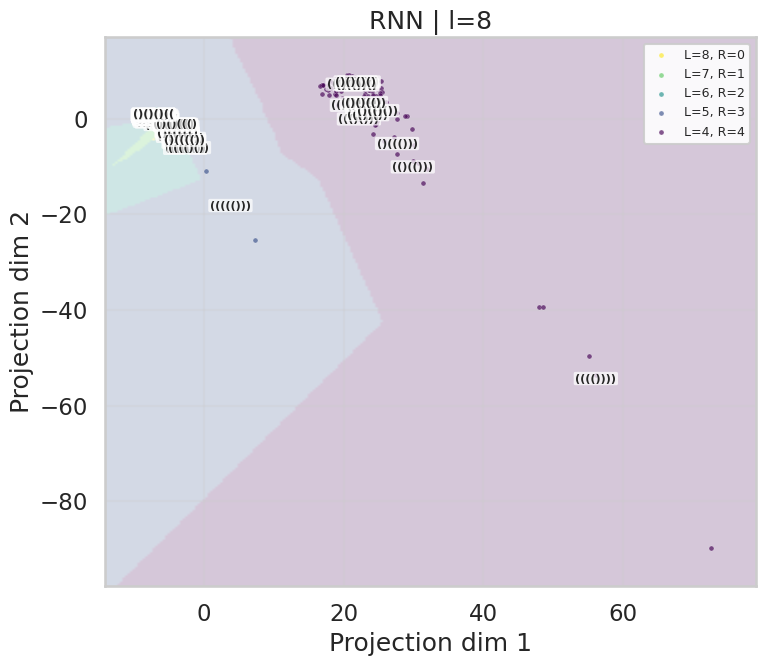

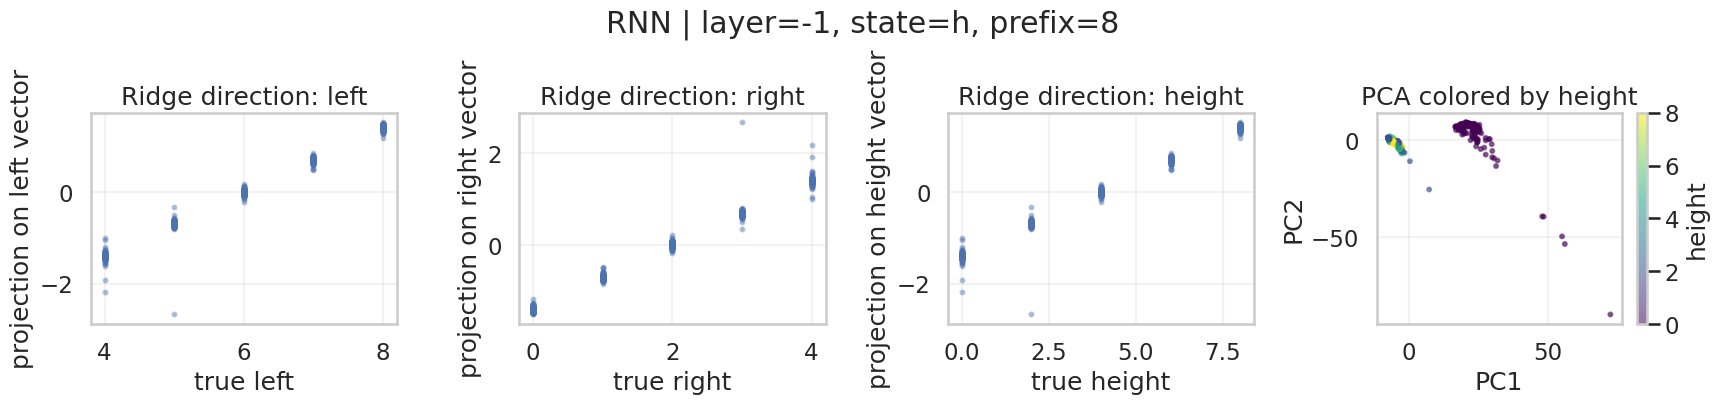

MODEL: lstm
lstm train raw height counts -> 0:5429, 2:8781, 4:4297, 6:1341, 8:152
lstm test raw height counts -> 0:5414, 2:8678, 4:4507, 6:1257, 8:144
lstm train balanced height counts -> 0:152, 2:152, 4:152, 6:152, 8:152
lstm test balanced height counts -> 0:144, 2:144, 4:144, 6:144, 8:144
   ridge       left        r2: 0.9965
   ridge       left       mae: 0.0627
   ridge      right        r2: 0.9965
   ridge      right       mae: 0.0627
   ridge     height        r2: 0.9965
   ridge     height       mae: 0.1254
logistic     height  accuracy: 0.9944
logistic     height n_classes: 5.0000
logistic    pair_id  accuracy: 0.9944
logistic    pair_id n_classes: 5.0000
logistic next_token  accuracy: 0.5917
logistic next_token n_classes: 2.0000
Cosine similarities between learned Ridge directions:
    left: +1.000  -1.000  +1.000
   right: -1.000  +1.000  -1.000
  height: +1.000  -1.000  +1.000


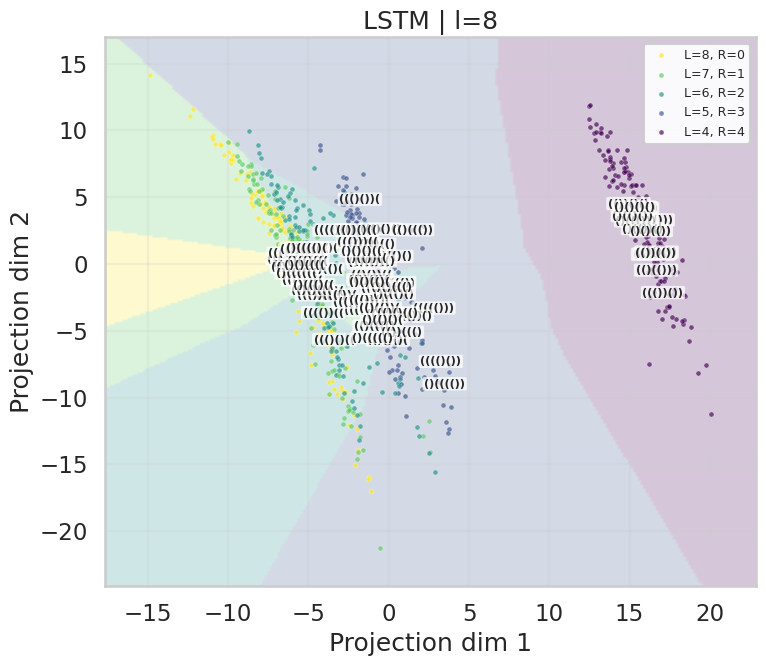

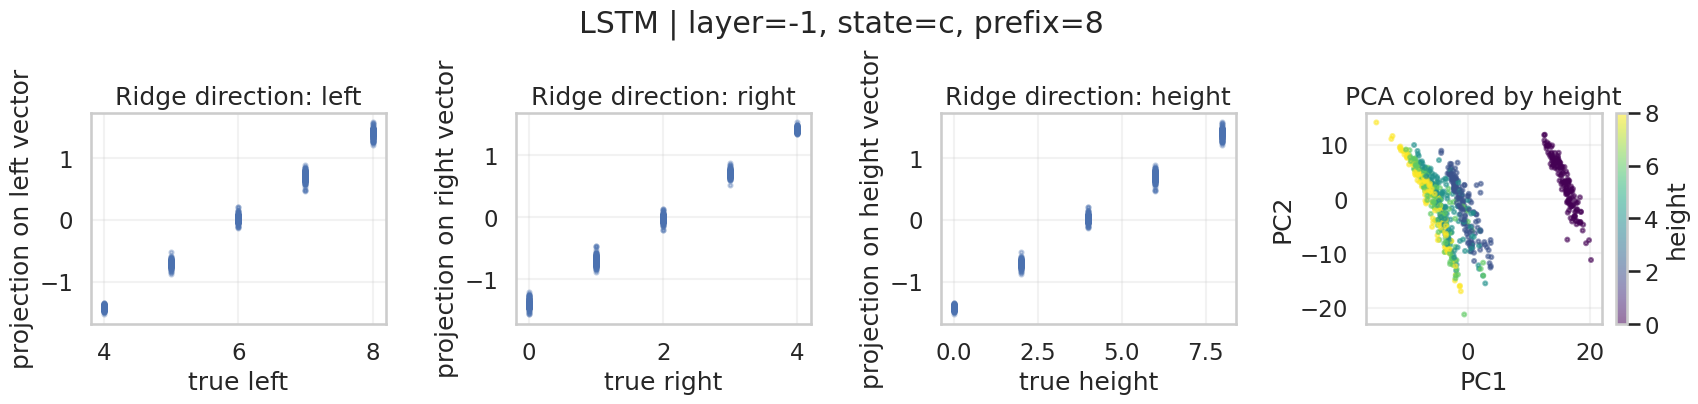

MODEL: transformer
transformer train raw height counts -> 0:5429, 2:8781, 4:4297, 6:1341, 8:152
transformer test raw height counts -> 0:5414, 2:8678, 4:4507, 6:1257, 8:144
transformer train balanced height counts -> 0:152, 2:152, 4:152, 6:152, 8:152
transformer test balanced height counts -> 0:144, 2:144, 4:144, 6:144, 8:144
   ridge       left        r2: 0.9752
   ridge       left       mae: 0.0995
   ridge      right        r2: 0.9752
   ridge      right       mae: 0.0995
   ridge     height        r2: 0.9752
   ridge     height       mae: 0.1990
logistic     height  accuracy: 0.9875
logistic     height n_classes: 5.0000
logistic    pair_id  accuracy: 0.9875
logistic    pair_id n_classes: 5.0000
logistic next_token  accuracy: 0.5792
logistic next_token n_classes: 2.0000
Cosine similarities between learned Ridge directions:
    left: +1.000  -1.000  +1.000
   right: -1.000  +1.000  -1.000
  height: +1.000  -1.000  +1.000


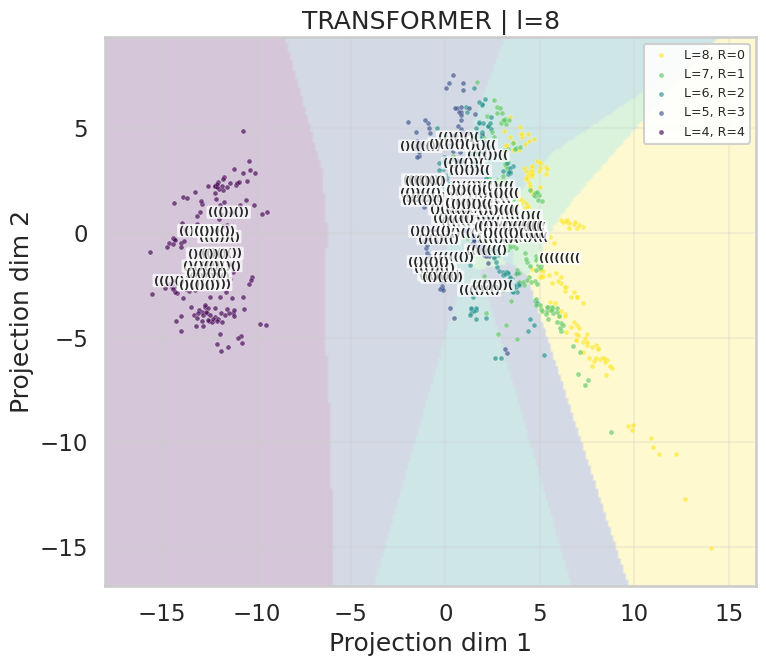

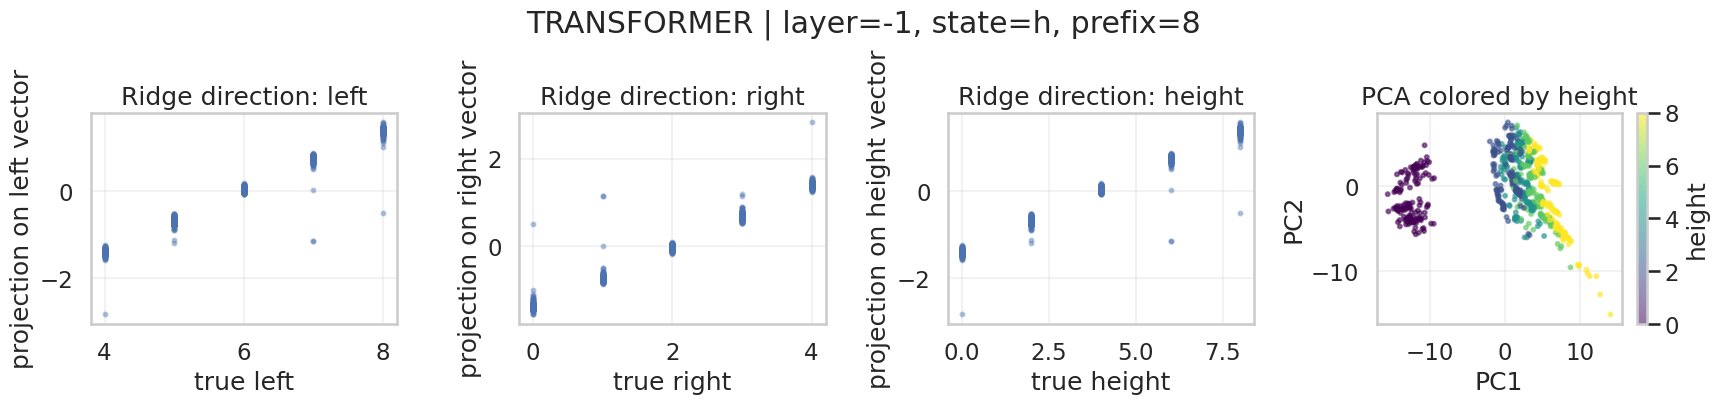

MODEL: mamba
mamba train raw height counts -> 0:5429, 2:8781, 4:4297, 6:1341, 8:152
mamba test raw height counts -> 0:5414, 2:8678, 4:4507, 6:1257, 8:144
mamba train balanced height counts -> 0:152, 2:152, 4:152, 6:152, 8:152
mamba test balanced height counts -> 0:144, 2:144, 4:144, 6:144, 8:144
   ridge       left        r2: 0.9915
   ridge       left       mae: 0.0983
   ridge      right        r2: 0.9915
   ridge      right       mae: 0.0983
   ridge     height        r2: 0.9915
   ridge     height       mae: 0.1965
logistic     height  accuracy: 0.9903
logistic     height n_classes: 5.0000
logistic    pair_id  accuracy: 0.9903
logistic    pair_id n_classes: 5.0000
logistic next_token  accuracy: 0.5875
logistic next_token n_classes: 2.0000
Cosine similarities between learned Ridge directions:
    left: +1.000  -1.000  +1.000
   right: -1.000  +1.000  -1.000
  height: +1.000  -1.000  +1.000


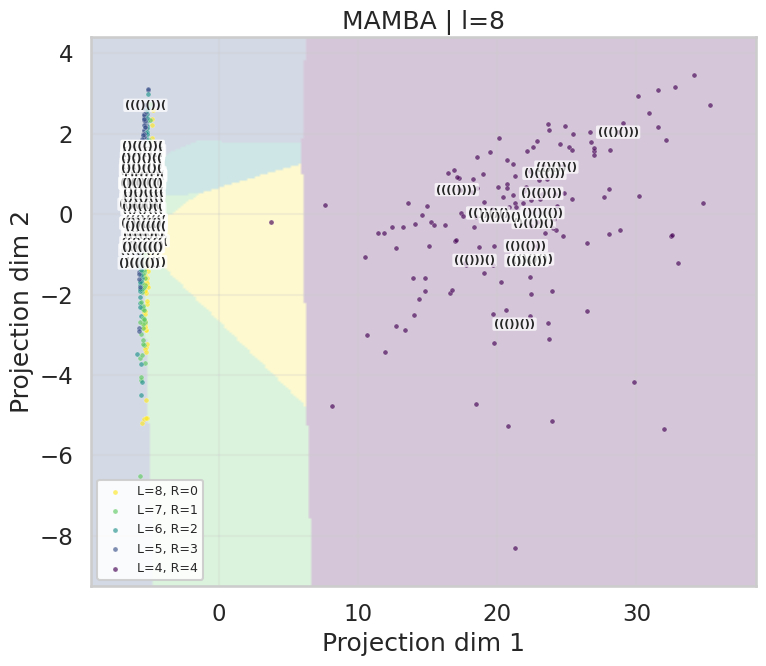

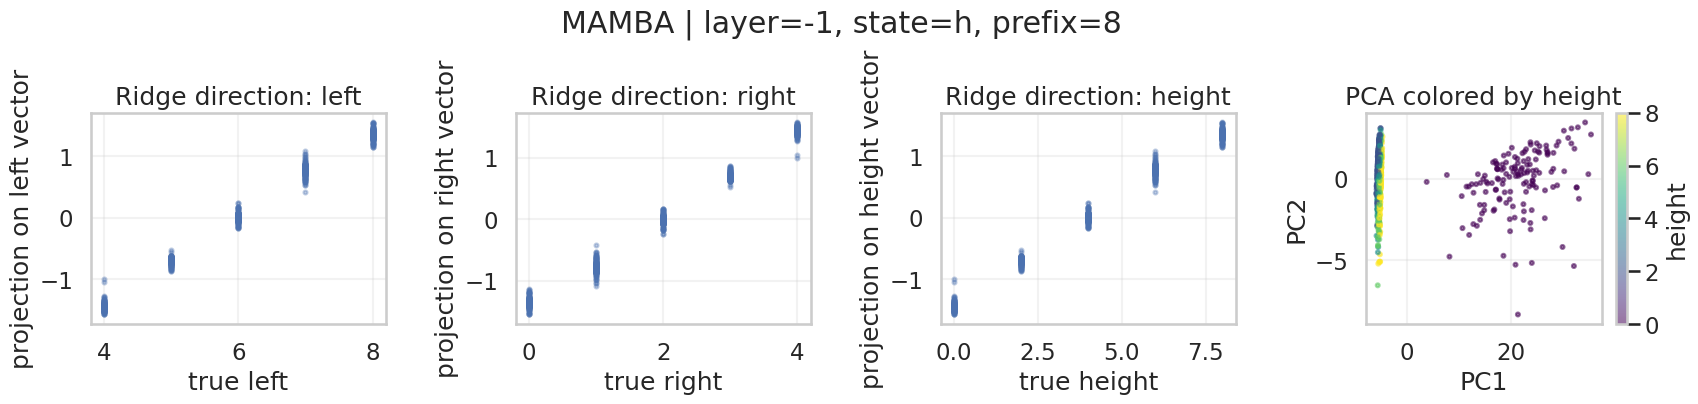

In [28]:
all_results = {}

for model_type in MODEL_TYPES:
    print("=" * 80)
    print(f"MODEL: {model_type}")
    payload = loaded_models[model_type]
    model = payload["model"]
    state_kind = STATE_KIND_BY_MODEL[model_type]

    train_data = sample_hidden_count_matrix(
        model,
        make_sampler(seed_offset=300),
        prefix_length=PREFIX_LENGTH,
        layer_index=LAYER_INDEX,
        state_kind=state_kind,
        n_samples=N_PROBE_SAMPLES,
    )
    test_data = sample_hidden_count_matrix(
        model,
        make_sampler(seed_offset=400),
        prefix_length=PREFIX_LENGTH,
        layer_index=LAYER_INDEX,
        state_kind=state_kind,
        n_samples=N_PROBE_SAMPLES,
    )

    print_class_balance(train_data, BALANCE_PROBE_BY, name=f"{model_type} train raw")
    print_class_balance(test_data, BALANCE_PROBE_BY, name=f"{model_type} test raw")
    train_probe_data = balance_data_by_label(train_data, BALANCE_PROBE_BY, seed=BALANCE_SEED)
    test_probe_data = balance_data_by_label(test_data, BALANCE_PROBE_BY, seed=BALANCE_SEED + 1)
    print_class_balance(train_probe_data, BALANCE_PROBE_BY, name=f"{model_type} train balanced")
    print_class_balance(test_probe_data, BALANCE_PROBE_BY, name=f"{model_type} test balanced")

    rows, fitted = run_counting_probes(train_probe_data, test_probe_data)
    all_results[model_type] = {
        "rows": rows,
        "fitted": fitted,
        "train_data": train_data,
        "test_data": test_data,
        "train_probe_data": train_probe_data,
        "test_probe_data": test_probe_data,
    }

    for row in rows:
        print(f"{row['probe']:>8s} {row['target']:>10s} {row['metric']:>9s}: {row['value']:.4f}")

    summarize_counting_directions(fitted)
    plot_prefix_scatter_by_count_pair(
        test_probe_data,
        title=f"{model_type.upper()} | l={PREFIX_LENGTH}",
        open_token=make_sampler(seed_offset=0).config.open_token,
        close_token=make_sampler(seed_offset=0).config.close_token,
    )
    plot_counting_projection(
        test_probe_data,
        fitted,
        title=f"{model_type.upper()} | layer={LAYER_INDEX}, state={state_kind}, prefix={PREFIX_LENGTH}",
    )

## 8. Prefix Sweep

PREFIX SWEEP: rnn
rnn prefix=2
rnn prefix=4
rnn prefix=6
rnn prefix=8
rnn prefix=10
rnn prefix=12
rnn prefix=14
rnn prefix=16
rnn prefix=18
rnn prefix=20
PREFIX SWEEP: lstm
lstm prefix=2
lstm prefix=4
lstm prefix=6
lstm prefix=8
lstm prefix=10
lstm prefix=12
lstm prefix=14
lstm prefix=16
lstm prefix=18
lstm prefix=20
PREFIX SWEEP: transformer
transformer prefix=2
transformer prefix=4
transformer prefix=6
transformer prefix=8
transformer prefix=10
transformer prefix=12
transformer prefix=14
transformer prefix=16
transformer prefix=18
transformer prefix=20
PREFIX SWEEP: mamba
mamba prefix=2
mamba prefix=4
mamba prefix=6
mamba prefix=8
mamba prefix=10
mamba prefix=12
mamba prefix=14
mamba prefix=16
mamba prefix=18
mamba prefix=20


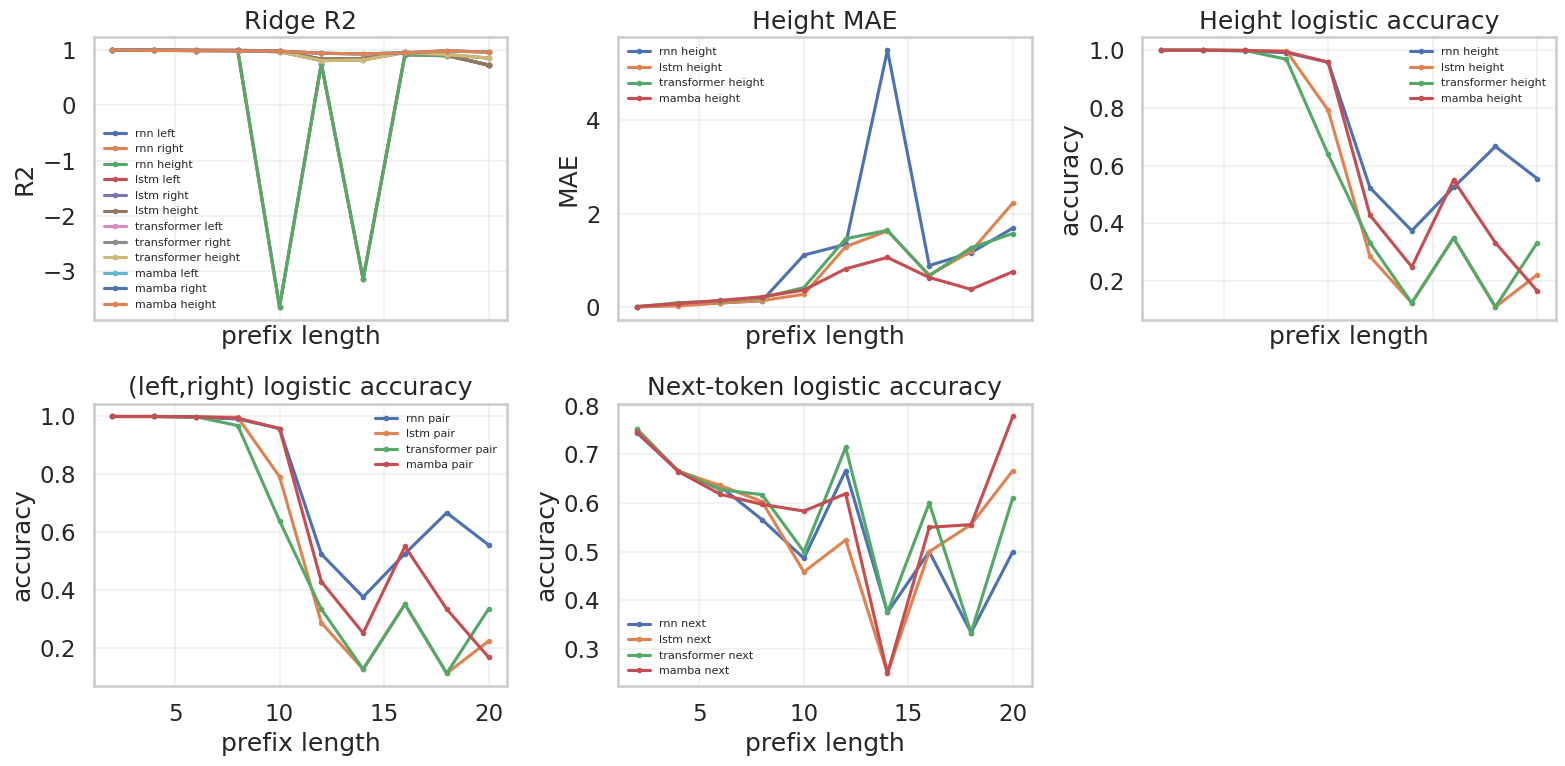

In [29]:
def _rows_to_lookup(rows):
    lookup = {}
    for row in rows:
        lookup[(row["probe"], row["target"], row["metric"])] = row["value"]
    return lookup


def run_prefix_sweep_for_model(model_type):
    model = loaded_models[model_type]["model"]
    state_kind = STATE_KIND_BY_MODEL[model_type]
    sweep_rows = []
    directions = {}

    for prefix_length in SWEEP_PREFIX_LENGTHS:
        print(f"{model_type} prefix={prefix_length}")
        train_data = sample_hidden_count_matrix(
            model,
            make_sampler(seed_offset=600 + prefix_length),
            prefix_length=prefix_length,
            layer_index=LAYER_INDEX,
            state_kind=state_kind,
            n_samples=SWEEP_N_SAMPLES,
        )
        test_data = sample_hidden_count_matrix(
            model,
            make_sampler(seed_offset=700 + prefix_length),
            prefix_length=prefix_length,
            layer_index=LAYER_INDEX,
            state_kind=state_kind,
            n_samples=SWEEP_N_SAMPLES,
        )
        train_data = balance_data_by_label(train_data, BALANCE_PROBE_BY, seed=BALANCE_SEED)
        test_data = balance_data_by_label(test_data, BALANCE_PROBE_BY, seed=BALANCE_SEED + 1)

        rows, fitted = run_counting_probes(train_data, test_data)
        lookup = _rows_to_lookup(rows)
        row = {"model": model_type, "prefix": prefix_length}
        for target in ["left", "right", "height"]:
            row[f"{target}_r2"] = lookup[("ridge", target, "r2")]
            row[f"{target}_mae"] = lookup[("ridge", target, "mae")]
        row["height_acc"] = lookup[("logistic", "height", "accuracy")]
        row["pair_acc"] = lookup[("logistic", "pair_id", "accuracy")]
        if ("logistic", "next_token", "accuracy") in lookup:
            row["next_acc"] = lookup[("logistic", "next_token", "accuracy")]
        sweep_rows.append(row)

        directions[prefix_length] = {}
        for target in ["left", "right", "height"]:
            w = _ridge_direction(fitted[f"ridge_{target}"])
            directions[prefix_length][target] = w / (np.linalg.norm(w) + 1e-12)
    return sweep_rows, directions


prefix_sweep_results = {}
for model_type in MODEL_TYPES:
    print("=" * 80)
    print(f"PREFIX SWEEP: {model_type}")
    rows, directions = run_prefix_sweep_for_model(model_type)
    prefix_sweep_results[model_type] = {"rows": rows, "directions": directions}


def plot_prefix_sweep(prefix_sweep_results):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    for model_type, result in prefix_sweep_results.items():
        rows = result["rows"]
        prefixes = np.asarray([r["prefix"] for r in rows])
        for target in ["left", "right", "height"]:
            axes[0, 0].plot(prefixes, [r[f"{target}_r2"] for r in rows], marker="o", ms=3, label=f"{model_type} {target}")
        axes[0, 1].plot(prefixes, [r["height_mae"] for r in rows], marker="o", ms=3, label=f"{model_type} height")
        axes[0, 2].plot(prefixes, [r["height_acc"] for r in rows], marker="o", ms=3, label=f"{model_type} height")
        axes[1, 0].plot(prefixes, [r["pair_acc"] for r in rows], marker="o", ms=3, label=f"{model_type} pair")
        next_rows = [r for r in rows if "next_acc" in r]
        if next_rows:
            next_prefixes = np.asarray([r["prefix"] for r in next_rows])
            next_accs = [r["next_acc"] for r in next_rows]
            axes[1, 1].plot(next_prefixes, next_accs, marker="o", ms=3, label=f"{model_type} next")

    axes[0, 0].set_title("Ridge R2")
    axes[0, 0].set_ylabel("R2")
    axes[0, 1].set_title("Height MAE")
    axes[0, 1].set_ylabel("MAE")
    axes[0, 2].set_title("Height logistic accuracy")
    axes[0, 2].set_ylabel("accuracy")
    axes[1, 0].set_title("(left,right) logistic accuracy")
    axes[1, 0].set_ylabel("accuracy")
    axes[1, 1].set_title("Next-token logistic accuracy")
    axes[1, 1].set_ylabel("accuracy")
    axes[1, 2].axis("off")

    for ax in axes.ravel():
        ax.set_xlabel("prefix length")
        ax.grid(True, alpha=0.25)
        if ax.has_data():
            ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


plot_prefix_sweep(prefix_sweep_results)

## 9. Direction Arithmetic

RNN
prefix | cos(left,right) | cos(height,left-right) | cos(height,left+right)
     2 | -1.000 | +1.000 | +0.000
     4 | -1.000 | +1.000 | +0.000
     6 | -1.000 | +1.000 | +0.000
     8 | -1.000 | +1.000 | +0.000
    10 | -1.000 | +1.000 | +0.000
    12 | -1.000 | +1.000 | +0.000
    14 | -1.000 | +1.000 | +0.000
    16 | -1.000 | +1.000 | +0.000
    18 | -1.000 | +1.000 | +0.000
    20 | -1.000 | +1.000 | +0.000
LSTM
prefix | cos(left,right) | cos(height,left-right) | cos(height,left+right)
     2 | -1.000 | +1.000 | +0.000
     4 | -1.000 | +1.000 | +0.000
     6 | -1.000 | +1.000 | +0.000
     8 | -1.000 | +1.000 | +0.000
    10 | -1.000 | +1.000 | +0.000
    12 | -1.000 | +1.000 | +0.000
    14 | -1.000 | +1.000 | +0.000
    16 | -1.000 | +1.000 | +0.000
    18 | -1.000 | +1.000 | +0.000
    20 | -1.000 | +1.000 | +0.000
TRANSFORMER
prefix | cos(left,right) | cos(height,left-right) | cos(height,left+right)
     2 | -1.000 | +1.000 | +0.000
     4 | -1.000 | +1.000 | +0.000
     6

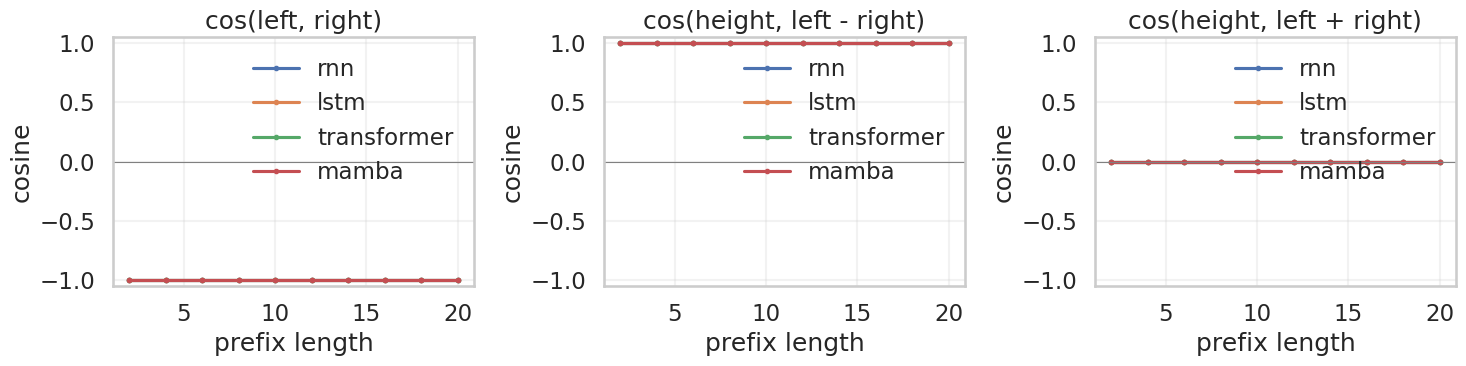

In [30]:
def direction_arithmetic_table(prefix_sweep_results):
    rows = []
    for model_type, result in prefix_sweep_results.items():
        directions = result["directions"]
        for prefix, d in directions.items():
            w_left = d["left"]
            w_right = d["right"]
            w_height = d["height"]
            w_diff = w_left - w_right
            w_sum = w_left + w_right
            w_diff = w_diff / (np.linalg.norm(w_diff) + 1e-12)
            w_sum = w_sum / (np.linalg.norm(w_sum) + 1e-12)
            rows.append({
                "model": model_type,
                "prefix": prefix,
                "cos_left_right": float(np.dot(w_left, w_right)),
                "cos_height_left_minus_right": float(np.dot(w_height, w_diff)),
                "cos_height_left_plus_right": float(np.dot(w_height, w_sum)),
            })
    return rows


direction_arithmetic_rows = direction_arithmetic_table(prefix_sweep_results)

for model_type in MODEL_TYPES:
    print("=" * 80)
    print(model_type.upper())
    rows = [r for r in direction_arithmetic_rows if r["model"] == model_type]
    print("prefix | cos(left,right) | cos(height,left-right) | cos(height,left+right)")
    for r in rows:
        print(
            f"{r['prefix']:>6d} | {r['cos_left_right']:+.3f} | {r['cos_height_left_minus_right']:+.3f} | {r['cos_height_left_plus_right']:+.3f}"
        )


def plot_direction_arithmetic(direction_arithmetic_rows):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    metrics = [
        ("cos_left_right", "cos(left, right)"),
        ("cos_height_left_minus_right", "cos(height, left - right)"),
        ("cos_height_left_plus_right", "cos(height, left + right)"),
    ]
    for ax, (key, title) in zip(axes, metrics):
        for model_type in MODEL_TYPES:
            rows = [r for r in direction_arithmetic_rows if r["model"] == model_type]
            prefixes = [r["prefix"] for r in rows]
            vals = [r[key] for r in rows]
            ax.plot(prefixes, vals, marker="o", ms=3, label=model_type)
        ax.axhline(0, color="gray", lw=0.8)
        ax.set_title(title)
        ax.set_xlabel("prefix length")
        ax.set_ylabel("cosine")
        ax.set_ylim(-1.05, 1.05)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


plot_direction_arithmetic(direction_arithmetic_rows)